# Single Neuron with TensorFlow: AND, OR, and XOR Problem



## 1. Introduction

An Artificial Neural Network (ANN) is a machine learning model inspired by the way biological neurons process information.

The simplest building block of an ANN is a **single neuron** (also called a **perceptron**). A single neuron receives input values, assigns importance to each input using weights, adds a bias, and produces an output using an activation function.

A single neuron can be used for binary classification problems where the output belongs to one of two classes:

- 0 → Negative class
- 1 → Positive class


## Mathematical Representation of a Neuron

A neuron first calculates a weighted sum of its inputs:

$$
z = w_1x_1 + w_2x_2 + ... + w_nx_n + b
$$


Where:

- $x_1, x_2, ..., x_n$ → input features
- $w_1, w_2, ..., w_n$ → weights learned during training
- $b$ → bias term
- $z$ → linear combination of inputs


Then, the neuron applies an activation function to produce the final output:

$$
\hat{y} = \sigma(z)
$$


For binary classification, we usually use the **Sigmoid activation function**:


$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$


The sigmoid function converts any value into a probability between 0 and 1:

- Values close to 0 → class 0
- Values close to 1 → class 1


## Training a Neuron

During training, the neuron tries to find the best values for:

- Weights ($w$)
- Bias ($b$)

by minimizing the difference between the predicted output and the true output.

For binary classification, we use **Binary Cross Entropy (BCE)** as the loss function:


$$
Loss = -\frac{1}{m}\sum_{i=1}^{m}
[y_i\log(\hat{y_i})+(1-y_i)\log(1-\hat{y_i})]
$$


where:

- $y_i$ → actual label
- $\hat{y_i}$ → predicted probability
- $m$ → number of samples


## Goal of This Notebook

In this notebook, we will train a single neuron using TensorFlow/Keras to learn three logical operations:

### 1. AND Gate ✅

A single neuron can learn AND because the data is **linearly separable**.


### 2. OR Gate ✅

A single neuron can also learn OR because it has a linear decision boundary.


### 3. XOR Gate ❌

A single neuron fails to learn XOR because XOR is **not linearly separable**.

This limitation is one of the main reasons we need **multiple neurons and hidden layers** to build deeper neural networks.

## 2.Import Libaries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

I0000 00:00:1783583515.459009   28767 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783583519.365803   28767 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783583537.316444   28767 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 3. Create DataSets

In [ ]:
X_and = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_and = np.array([0,0,0,1])

In [ ]:
X_or = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_or = np.array([0,1,1,1])

In [ ]:
X_xor = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_xor = np.array([0,1,1,0])

## 4. Visualize Each Dataset

In [ ]:
def plot_ds(X, y, title):
    plt.figure(figsize=(5, 5))

    # Plot class 0
    plt.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        color="red",
        marker="o",
        s=120,
        label="Output = 0"
    )

    # Plot class 1
    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        color="blue",
        marker="^",
        s=120,
        label="Output = 1"
    )

    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.title(title)
    plt.xticks([0, 1])
    plt.yticks([0, 1])
    plt.xlim(-0.2, 1.2)
    plt.ylim(-0.2, 1.2)
    plt.grid(True)
    plt.legend()
    plt.show()

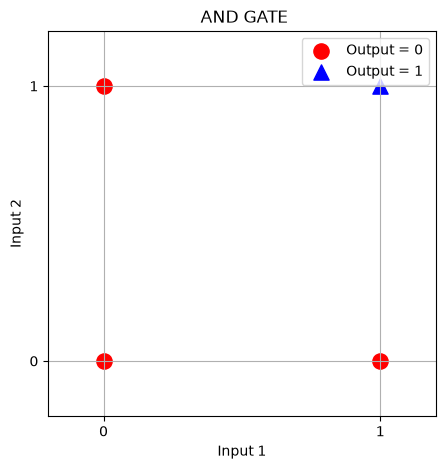

In [ ]:
plot_ds(X_and ,y_and , ' AND GATE' )


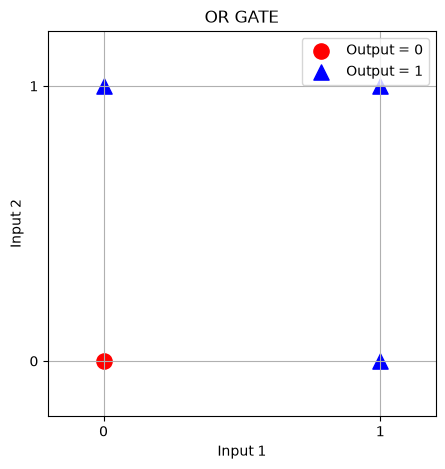

In [ ]:
plot_ds(X_or , y_or ,'OR GATE')

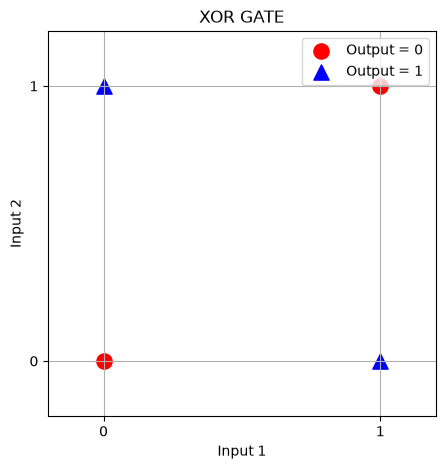

In [ ]:
plot_ds (X_xor ,y_xor,'XOR GATE')

## 5. Build a Single Neuron

In [ ]:
model = Sequential(
    [

        Dense(
            units= 1 ,
            activation= tf.keras.activations.sigmoid,
            input_shape=(2,)
        )
    ] 
)

/home/kyrillosmaher/python-envs/tfenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 6. Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 7. Train Model

In [ ]:
def train_model(model,X, y, title, epochs=500):

   
    history = model.fit(
        X,
        y,
        epochs=epochs,
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X,
        y,
        verbose=0
    )

    print("="*40)
    print(title)
    print("Accuracy:", accuracy)

    print("\nPredictions:")
    
    probs = model.predict(X, verbose=0)
    preds = (probs >= 0.5).astype(int)

    print(preds.reshape(-1))


    weights, bias = model.layers[0].get_weights()

    print("\nWeights:")
    print(weights)

    print("\nBias:")
    print(bias)


    return model, history

In [ ]:
and_model, and_history = train_model(
    model ,
    X_and,
    y_and,
    "AND Gate"
)

AND Gate
Accuracy: 1.0

Predictions:
[0 0 0 1]

Weights:
[[0.49026382]
 [0.4242082 ]]

Bias:
[-0.7890167]


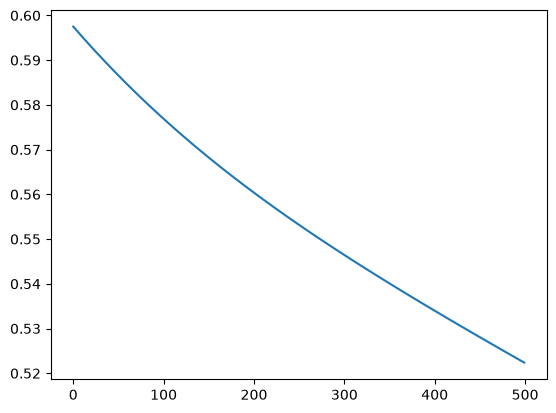

In [ ]:
plt.plot(and_history.history['loss'])

In [ ]:
or_model, or_history = train_model(
    model ,
    X_or,
    y_or,
    "OR Gate"
)

OR Gate
Accuracy: 1.0

Predictions:
[0 1 1 1]

Weights:
[[1.2452682]
 [1.1979274]]

Bias:
[-0.4490309]


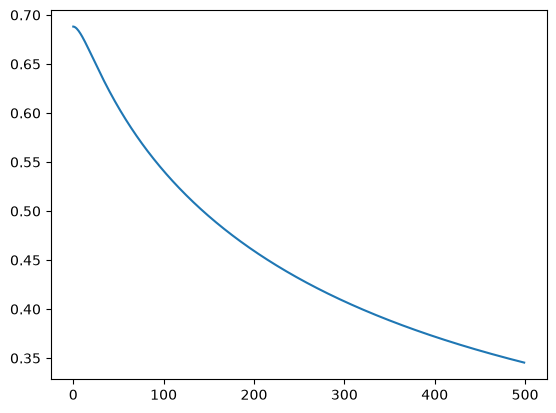

In [ ]:
plt.plot(or_history.history['loss'])

In [ ]:
xor_model, xor_history = train_model(
    model ,
    X_xor,
    y_xor,
    "XOR Gate"
)

XOR Gate
Accuracy: 0.75

Predictions:
[0 1 1 1]

Weights:
[[0.83352226]
 [0.7974068 ]]

Bias:
[-0.6659547]


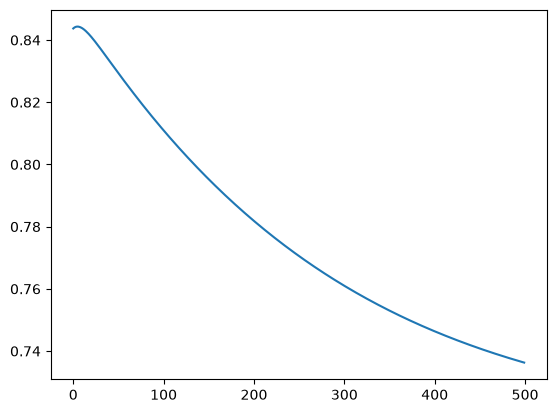

In [ ]:
plt.plot(xor_history.history['loss'])

## 8. Decision Boundary Visualization

In [ ]:
def plot_decision_boundary(model, X, y, title):

    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5


    xx, yy = np.meshgrid(
        np.linspace(x_min,x_max,200),
        np.linspace(y_min,y_max,200)
    )


    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]


    predictions = model.predict(
        grid,
        verbose=0
    )


    predictions = predictions.reshape(xx.shape)


    plt.figure(figsize=(6,5))


    plt.contourf(
        xx,
        yy,
        predictions,
        levels=[0,0.5,1],
        alpha=0.3
    )


    plt.scatter(
        X[:,0],
        X[:,1],
        c=y,
        s=100,
        edgecolors="black"
    )


    plt.xlabel("X1")
    plt.ylabel("X2")

    plt.title(title)

    plt.grid()

    plt.show()

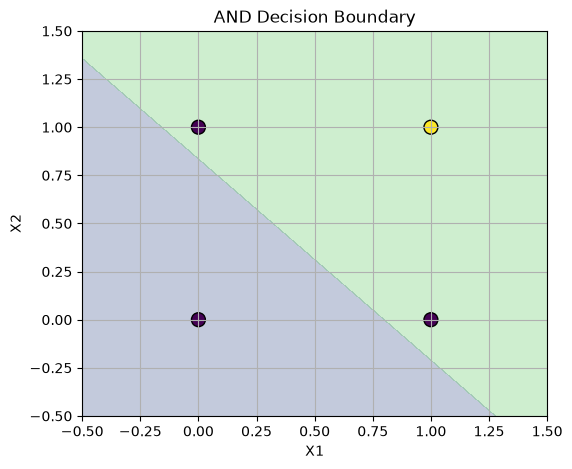

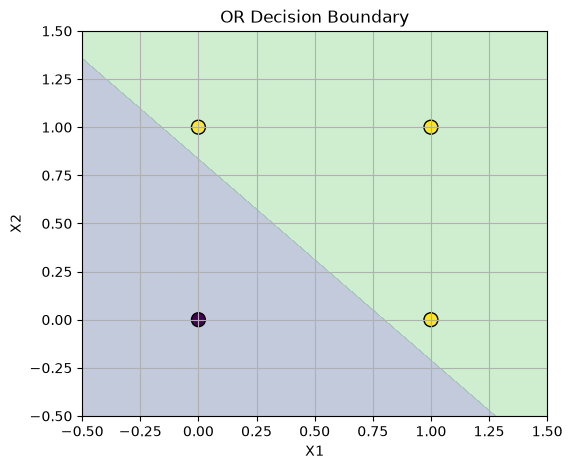

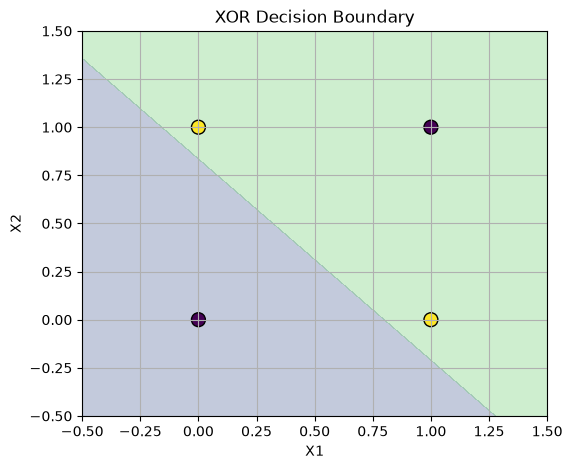

In [ ]:
plot_decision_boundary(
    and_model,
    X_and,
    y_and,
    "AND Decision Boundary"
)
plot_decision_boundary(
    or_model,
    X_or,
    y_or,
    "OR Decision Boundary"
)
plot_decision_boundary(
    xor_model,
    X_xor,
    y_xor,
    "XOR Decision Boundary"
)

## 9. Conclsion

In [ ]:
print("""
Single Neuron Results:

AND  -> Works ✅
OR   -> Works ✅
XOR  -> Fails ❌

Reason:
A single neuron can only learn linear decision boundaries.

Next:
Use hidden layers (MLP) to solve XOR.
""")


Single Neuron Results:

AND  -> Works ✅
OR   -> Works ✅
XOR  -> Fails ❌

Reason:
A single neuron can only learn linear decision boundaries.

Next:
Use hidden layers (MLP) to solve XOR.

